In [1]:
#IMPORTACION DE LIBERIAS

# Manejo de datos
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
load_dotenv()

USER = os.getenv('POSTGRES_USER')
PASSWORD = os.getenv('POSTGRES_PASSWORD')
HOST = os.getenv('POSTGRES_HOST')
PORT = os.getenv('POSTGRES_PORT') 
DB = os.getenv('POSTGRES_DB')

engine = create_engine(f'postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

print("Conexión a la base de datos establecida")

Conexión a la base de datos establecida


In [3]:
query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    i.price,
    i.freight_value,
    p.product_category_name
FROM olist_orders_dataset o
INNER JOIN olist_order_items_dataset i 
    ON o.order_id = i.order_id
INNER JOIN olist_products_dataset p 
    ON i.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name IS NOT NULL
  AND o.order_purchase_timestamp >= '2017-01-01'  ;
"""

In [4]:
# Extraemos el dataset maestro utilizando el motor de conexión que ya tenías (engine)
df_master = pd.read_sql(query, engine)

# Convertimos inmediatamente la fecha de texto a formato Datetime de Pandas
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])

print("Dataset maestro primera version")
print(df_master.info())
print()
print(df_master.head())


Dataset maestro primera version
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108345 entries, 0 to 108344
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  108345 non-null  object        
 1   order_purchase_timestamp  108345 non-null  datetime64[ns]
 2   price                     108345 non-null  float64       
 3   freight_value             108345 non-null  float64       
 4   product_category_name     108345 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 4.1+ MB
None

                           order_id order_purchase_timestamp  price  \
0  00018f77f2f0320c557190d7a144bdd3      2017-04-26 10:53:06  239.9   
1  000229ec398224ef6ca0657da4fc703e      2018-01-14 14:33:31  199.0   
2  00042b26cf59d7ce69dfabb4e55b4fd9      2017-02-04 13:57:51  199.9   
3  00048cc3ae777c65dbb7d2a0634bc1ea      2017-05-15 21:4

In [5]:
# 1. Preparación temporal (Agrupar por Año y Mes) de '2017-10-02 10:56:33' a '2017-10'
df_master['year_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')
# 'M' -> Toma la fecha y la recorta al periodo: mes +año

# Agrupamos contando cuántos artículos se vendieron en cada mes
ventas_mensuales = df_master.groupby('year_month').size().reset_index(name='total_articulos_vendidos')
#    year_month  total_articulos_vendidos
# 0     2023-01                       500

# Convertimos el periodo a texto para que se grafique
ventas_mensuales['year_month'] = ventas_mensuales['year_month'].astype(str)


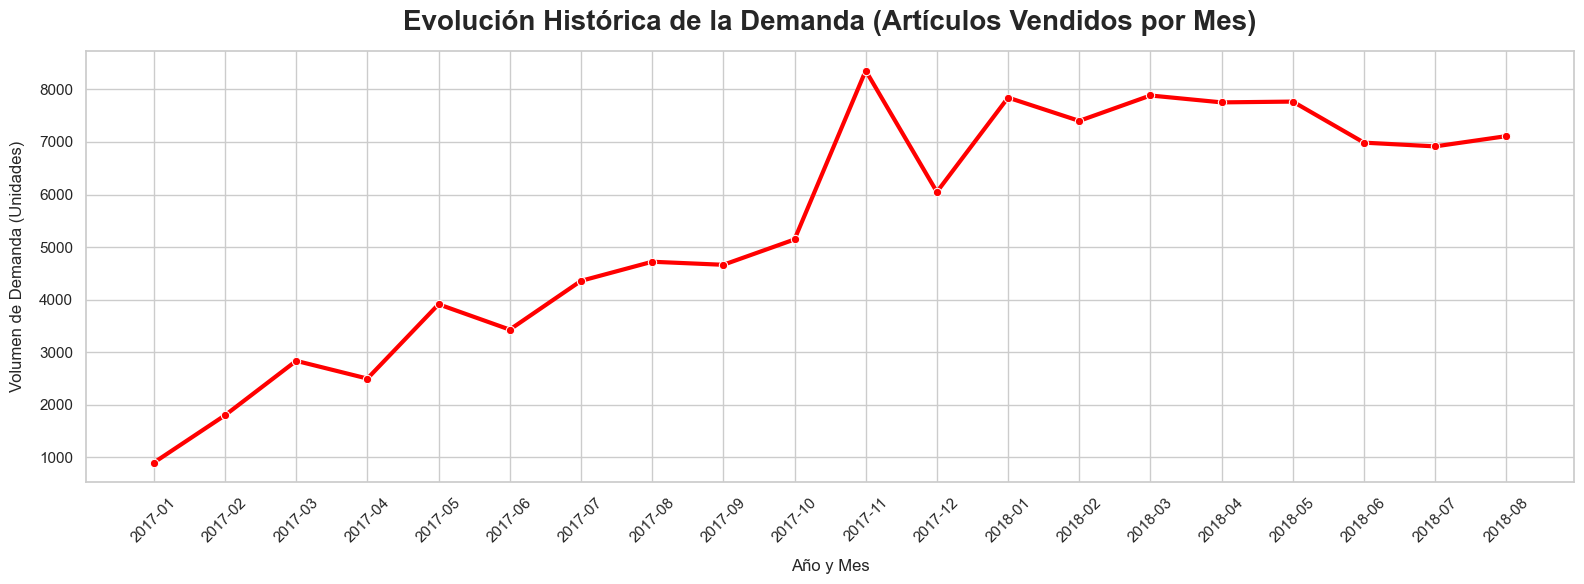

In [6]:
# Como se comporta la variable del tiempo.
sns.set_theme(style="whitegrid") # configurar el diseño estético global para todas las gráficas
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=ventas_mensuales, 
    x='year_month', 
    y='total_articulos_vendidos', 
    marker='o',                
    color="#ff0000",           
    linewidth=3
)
plt.title('Evolución Histórica de la Demanda (Artículos Vendidos por Mes)', fontsize=20, fontweight='bold', pad=15)
plt.xlabel('Año y Mes', fontsize=12, labelpad=10)
plt.ylabel('Volumen de Demanda (Unidades)', fontsize=12, labelpad=10)
plt.xticks(rotation=45) # Giramos las etiquetas del eje X
plt.tight_layout()
plt.show()

In [7]:
# Preparación Mínima (El "Mini" Feature Engineering)

# Extraccion de fechas
df_master['purchase_year'] = df_master['order_purchase_timestamp'].dt.year
df_master['purchase_month'] = df_master['order_purchase_timestamp'].dt.month
df_master['purchase_day'] = df_master['order_purchase_timestamp'].dt.day
df_master['purchase_day_number'] = df_master['order_purchase_timestamp'].dt.weekday

# Devuelven TRUE o FALSE, estos se vuelven a int
# is_black_friday (Noviembre)
df_master['is_black_friday'] = (df_master['purchase_month'] == 11).astype(int)
# is_weekend
df_master['is_weekend'] = (df_master['purchase_day_number'] >= 5 ).astype(int)
# is_free_shipping
df_master['is_free_shipping'] = (df_master['freight_value'] == 0).astype(int)

print(df_master.info())
print(df_master.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108345 entries, 0 to 108344
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  108345 non-null  object        
 1   order_purchase_timestamp  108345 non-null  datetime64[ns]
 2   price                     108345 non-null  float64       
 3   freight_value             108345 non-null  float64       
 4   product_category_name     108345 non-null  object        
 5   year_month                108345 non-null  period[M]     
 6   purchase_year             108345 non-null  int32         
 7   purchase_month            108345 non-null  int32         
 8   purchase_day              108345 non-null  int32         
 9   purchase_day_number       108345 non-null  int32         
 10  is_black_friday           108345 non-null  int32         
 11  is_weekend                108345 non-null  int32         
 12  is

- Crear el target mediante una agrupación. Este no existe actualmente como una columna solitaria en tu base de datos esperando a ser elegida.

- Cada fila representa un solo artículo vendido. Usando tu tabla actual tal como está, el algoritmo se confundirá y siempre predecirá 1.

- En Machine Learning, intentar predecir producto por producto en un e-commerce se topa con el peor enemigo de los algoritmos: La Dispersión de los Datos (Data Sparsity)

In [8]:
# Crea una combinacion para cada parametro del groupby
# Si en alguna fecha la categoria tuvo 0 ventas, Pandas no creará la fila con un cero; simplemente se saltará esa categoría en ese mes.

df_modelo = df_master.groupby(
    ['purchase_year', 'purchase_month', 'product_category_name']
    ).agg(  # Todo por mes - año - categoria
    target_demanda=('order_id', 'count'), # Target, cuantas ventas por categoria
    precio_promedio=('price', 'mean'), # Promedio del precio por categoria
    es_black_friday=('is_black_friday', 'max'), # Variable binaria
    es_fin_de_semana=('is_weekend', 'mean'),
    es_envio_gratis=('is_free_shipping', 'mean') 
).reset_index()

# Ordenamos por año y mes para que quede como una línea de tiempo real
df_modelo = df_modelo.sort_values(['purchase_year', 'purchase_month'])

print(df_modelo.sample(5))
print(df_modelo.info())

     purchase_year  purchase_month              product_category_name  \
593           2017              11  construcao_ferramentas_iluminacao   
83            2017               2                          papelaria   
144           2017               4                          alimentos   
837           2018               3                            bebidas   
48            2017               2                         brinquedos   

     target_demanda  precio_promedio  es_black_friday  es_fin_de_semana  \
593              10       219.948000                1          0.100000   
83               19       123.231579                0          0.315789   
144               8        61.412500                0          0.500000   
837              21        45.842857                0          0.095238   
48               66       141.718788                0          0.227273   

     es_envio_gratis  
593              0.0  
83               0.0  
144              0.0  
837              0

En esta parte de la preparacion de los datos, no podemos hacer un split tradicionarl, ya que las fechas estarian mezcladas y haria del entrenamiento algo catastrofico.

Haremos una separacion de fechas con forma 75/25 basandonos en el tiempo (20 meses): dejamos 15 meses para entrenar (Train) y 5 meses para examinar (Test). Eso equivale a un 75/25.

In [9]:
# 1. Definimos la máscara temporal 
# A partir de Abril 2018 será Test
mask_test = (df_modelo['purchase_year'] == 2018) & (df_modelo['purchase_month'] >= 4)

# 2. Dividimos el DataFrame cronológicamente
df_train = df_modelo[~mask_test]
df_test = df_modelo[mask_test]  

print(f"Filas para Entrenamiento: {len(df_train)}")
print(f"Filas para Prueba: {len(df_test)}")

# 3. Separamos X y Y (Target) para ambos conjuntos
# y
y_train = df_train['target_demanda']
y_test = df_test['target_demanda']

# Los algoritmos basados en árboles de decisión (como tu Random Forest) son geniales interpolando (conectando puntos conocidos), pero son pésimos extrapolando (adivinando el futuro)
# El modelo interpreta ese 1 a 12 como una magnitud lineal de tamaño o valor. Pensará que el mes 12 (Diciembre) "vale el doble" que el mes 6 (Junio).

columnas_a_tirar = ['target_demanda', 'purchase_year', 'purchase_month']
X_train = df_train.drop(columns=columnas_a_tirar)
X_test = df_test.drop(columns=columnas_a_tirar)

Filas para Entrenamiento: 894
Filas para Prueba: 327


## ColumnTransformer para l preprocesamiento de datos
Sirve para aplicar diferentes transformaciones a diferentes columnas de tu dataset de forma simultánea y automática, devolviendo un único conjunto de datos unificado y listo para entrenar un modelo de Machine Learning.

ColumnTransformer hace todo en un solo paso. Le pasas una lista de reglas (tuplas) donde le indicas: "Aplica este transformador, a esta lista específica de columnas".

## Pipeline para procesamiento en orden
Sirve para encadenar de forma secuencial múltiples pasos de procesamiento de datos junto con el modelo final (estimador). Su objetivo es empaquetar todo tu flujo de trabajo de Machine Learning en un solo objeto.

El Pipeline automatiza todo esto. Tomas tu preprocesador, tomas tu modelo matemático, los unes, y a partir de ese momento actúan como si fueran un solo ente.

Puedes poner tantos pasos como quieras, y lo que regresa depende exclusivamente de lo que pongas al final de la fila. Todos los pasos intermedios DEBEN ser Transformadores: Es decir, cualquier paso que no sea el último tiene que ser capaz de recibir datos, modificarlos y pasarlos al siguiente. El comportamiento de todo tu Pipeline se define por el último paso que le agregues.

In [10]:

preprocesador = ColumnTransformer(
    transformers=[ # (nombre_paso, transformador, lista_de_columnas)
        # 'handle_unknown=ignore': si en Test aparece una categoría nueva (no en train), esta no rompe el código, la vuelve ceros.
        ('categorico', OneHotEncoder(handle_unknown='ignore'), ['product_category_name'])
    ],
    remainder='passthrough' # Deja pasar intactas el resto de columnas 
)

pipeline_rf = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', RandomForestRegressor(n_estimators=100, random_state=12345))
])

pipeline_rf.fit(X_train, y_train) # pasamos los datos enteros, el pipeline se encarga de las transformaciones

print("¡Modelo Baseline entrenado exitosamente!")

¡Modelo Baseline entrenado exitosamente!


In [11]:
predicciones = pipeline_rf.predict(X_test) # Predicciones

# Calcular metricas 
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)


print(" RESULTADOS DEL MODELO BASELINE (DATOS DE PRUEBA)")
print(f"MAE  (Error Absoluto Medio) : {mae:.2f} unidades")
print(f"RMSE (Error Cuadrático)     : {rmse:.2f} unidades")
print(f"R²   (Poder Explicativo)    : {r2:.4f} ({(r2*100):.1f}%)")

 RESULTADOS DEL MODELO BASELINE (DATOS DE PRUEBA)
MAE  (Error Absoluto Medio) : 39.80 unidades
RMSE (Error Cuadrático)     : 84.57 unidades
R²   (Poder Explicativo)    : 0.7771 (77.7%)


In [12]:
# Crear un nuevo pipeline para este modelo
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LinearRegression())
])

pipeline_lr.fit(X_train, y_train)

predicciones_lr = pipeline_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, predicciones_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, predicciones_lr))
r2_lr = r2_score(y_test, predicciones_lr)

print("RESULTADOS: REGRESIÓN LINEAL BASELINE")
print(f"MAE  (Error Absoluto Medio) : {mae_lr:.2f} unidades")
print(f"RMSE (Error Cuadrático)     : {rmse_lr:.2f} unidades")


RESULTADOS: REGRESIÓN LINEAL BASELINE
MAE  (Error Absoluto Medio) : 46.80 unidades
RMSE (Error Cuadrático)     : 92.79 unidades


# ¿Por qué hicimos este Baseline?
- Prueba de sanidad (Sanity Check): Confirmar que no hay errores masivos en SQL o en la limpieza
- El piso matemático: Nos da un punto de comparación.

# ¿Cómo sabemos si los datos y el modelo son "Viables"?
La viabilidad se mide en dos frentes: el técnico y el de negocio.

Viabilidad Técnica (¿Hay señal en el ruido?): La informacion proporcionada realmente tiene influencia en el resultado
Viabilidad de Negocio (El contexto del error): Tuvimos un MAE de 40 unidades. ¿Eso es bueno o malo? Depende del producto.

In [13]:
df_modelo.to_parquet('datos_modelo_limpio.parquet', index=False) # No estamos guardando un modelo, sino la matriz de datos
print("¡Datos exportados exitosamente!")

¡Datos exportados exitosamente!
